Generate synthetic datasets with same number of points N=10,000 and differ in number of dimensions and number of clusters. Compare results for LSH vs Grid.

For grid choose M using heuristic

For LSH use default parameters

In [1]:
import numpy as np 
from sklearn.datasets import make_blobs
from sklearn.preprocessing import MinMaxScaler
from bucket import create_bucket_synopsis, bucket_using_privacy_accountant, Params
from evaluation_utils import kmeans_loss
from lloyd import lloyd_with_weights

# d - dimension
# k - number of clusters
# n - number of points
def make_dataset(d: int, k: int, n: int=10000):
    data, _ = make_blobs(n_samples=n, n_features=d, centers=k)
    print(type(data))
    # now normalise it to (-1,1) meaning a radius of 1.4
    scaler = MinMaxScaler((-1,1))
    normalised_data = scaler.fit_transform(data)
    return normalised_data

master_rng = np.random.default_rng(42)
def lsh_experiment(algo: int, data: np.ndarray, p: Params, n_trials: int = 20, ps=0.8):
    s = master_rng.integers(low=0, high=100000)
    total_loss = 0
    n_successful_trials = n_trials
    for x in range(n_trials):
        if algo == 1:
            print("starting synopsis... ")
            private_points, private_weights = create_bucket_synopsis(data, p, s+x, privacy_split=ps)
        else:
            private_points, private_weights = bucket_using_privacy_accountant(data, p, s+x)
        if private_points.shape[0] <= p.k: # if number of points is less than or equal to desired number of centers
            centers = private_points
        else:
            centers = lloyd_with_weights(k=p.k, X=private_points, weights=private_weights, n_iter=10, rs=s+x)
        try:
            loss = kmeans_loss(centers, data)
        except:
            loss = 0
            n_successful_trials -=1
        total_loss += loss
        print(f"Trial {x+1} done")
    print("Number completed trials: ", n_successful_trials)
    return total_loss / n_successful_trials

In [2]:
data = make_dataset(d=10, k=5)
p = Params(epsilon=1, delta=1e-6, radius=1.4, dimension=10, k=5, max_depth=10)
losses = []

for s in range(5,96,5):
    privacy_split = s / 100
    print("privacy split:", privacy_split)
    avg_loss = lsh_experiment(1, data, p, n_trials=50, ps=privacy_split)
    losses.append(avg_loss)


<class 'numpy.ndarray'>
privacy split: 0.05
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 2682 
 include_threshold: 894
Trial 1 done
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 2682 
 include_threshold: 894
Trial 2 done
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 2682 
 include_threshold: 894
Trial 3 done
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 2682 
 include_threshold: 894
Trial 4 done
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 2682 
 include_threshold: 894
Trial 5 done
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 2682 
 include_threshold: 894
Trial 6 done
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 2682 
 include_threshold: 894
Trial 7 done
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 2682 
 include_threshold: 894
Trial 8 done
star

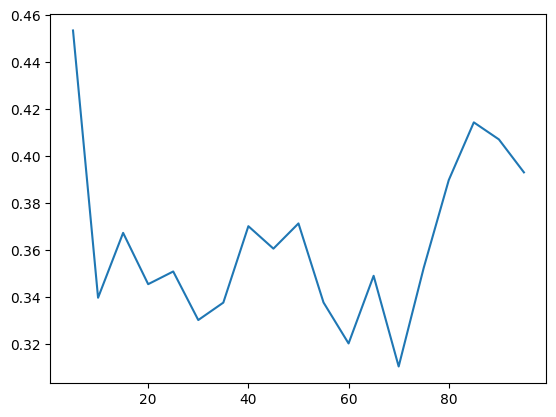

In [18]:
import matplotlib.pyplot as plt
plt.plot(list(range(5, 96, 5)), losses)

In [3]:
# d in range 2 -> 100
# k in range 2 -> 100

d_vals = list(range(10, 101, 10)) 
k_vals = list(range(10, 101, 10))

loss_grid = np.zeros((len(d_vals), len(k_vals)))

for i, d in enumerate(d_vals):
    for j, k in enumerate(k_vals):
        data = make_dataset(d, k)
        p = Params(epsilon=1, delta=1e-6, radius=1.4, dimension=d, k=k, max_depth=10)
        loss = lsh_experiment(1, data, p, n_trials=50)
        loss_grid[i, j] = loss

<class 'numpy.ndarray'>
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 336 
 include_threshold: 112
Trial 1 done
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 336 
 include_threshold: 112
Trial 2 done
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 336 
 include_threshold: 112
Trial 3 done
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 336 
 include_threshold: 112
Trial 4 done
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 336 
 include_threshold: 112
Trial 5 done
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 336 
 include_threshold: 112
Trial 6 done
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 336 
 include_threshold: 112
Trial 7 done
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 336 
 include_threshold: 112
Trial 8 done
starting synopsis... 
Parameters

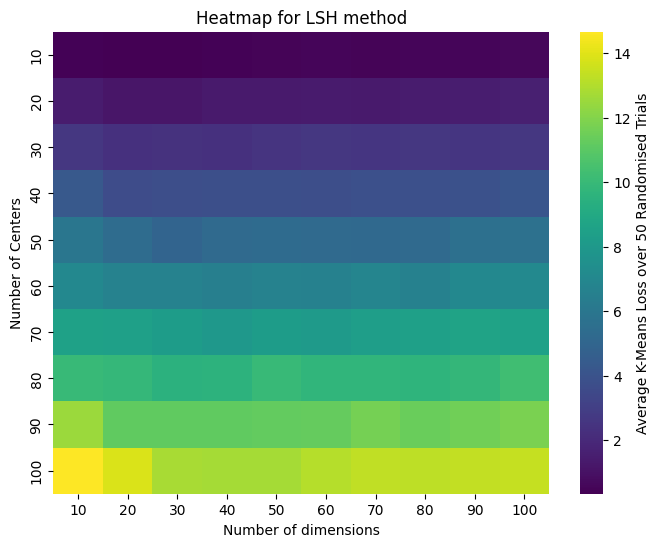

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(loss_grid,
            xticklabels=np.round(d_vals, 2),
            yticklabels=np.round(k_vals, 2),
            cmap="viridis",
            cbar_kws={"label": "Average K-Means Loss over 50 Randomised Trials"} )

plt.xlabel("Number of dimensions")
plt.ylabel("Number of Centers")
plt.title("Heatmap for LSH method")
plt.show()

In [2]:
# d in range 2 -> 100
# k in range 2 -> 100

d_vals = list(range(5, 20, 1)) 
k_vals = list(range(2, 13, 1))

loss_grid_lsh = np.zeros((len(d_vals), len(k_vals)))

for i, d in enumerate(d_vals):
    for j, k in enumerate(k_vals):
        data = make_dataset(d, k)
        p = Params(epsilon=1, delta=1e-6, radius=1.4, dimension=d, k=k, max_depth=10)
        loss = lsh_experiment(1, data, p, n_trials=20)
        loss_grid_lsh[i, j] = loss

<class 'numpy.ndarray'>
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 2352 
 include_threshold: 784
using gaussian mechanism
Trial 1 done
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 2352 
 include_threshold: 784
using gaussian mechanism
Trial 2 done
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 2352 
 include_threshold: 784
using gaussian mechanism
Trial 3 done
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 2352 
 include_threshold: 784
using gaussian mechanism
Trial 4 done
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 2352 
 include_threshold: 784
using gaussian mechanism
Trial 5 done
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 2352 
 include_threshold: 784
using gaussian mechanism
Trial 6 done
starting synopsis... 
Parameters used 
 max depth: 10
 branching threshold: 2352 
 include_threshold: 784
using 

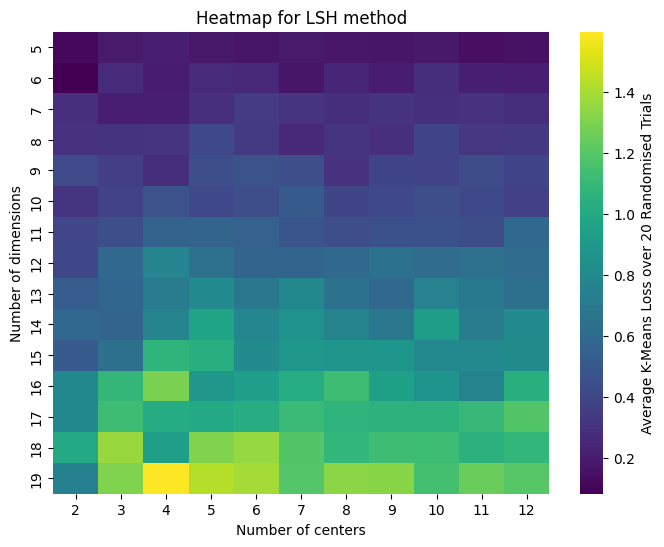

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(loss_grid_lsh,
            xticklabels=np.round(k_vals, 2),
            yticklabels=np.round(d_vals, 2),
            cmap="viridis",
            cbar_kws={"label": "Average K-Means Loss over 20 Randomised Trials"} )

plt.xlabel("Number of centers")
plt.ylabel("Number of dimensions")
plt.title("Heatmap for LSH method")
plt.show()

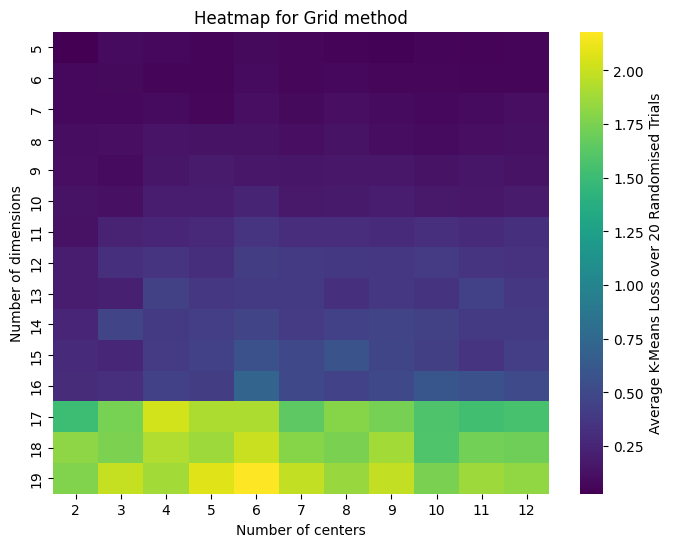

(15, 11)


In [5]:
loss_grid_grid = np.load("results/GRID_RESULTS.npy")

plt.figure(figsize=(8, 6))
sns.heatmap(loss_grid_grid,
            xticklabels=np.round(k_vals, 2),
            yticklabels=np.round(d_vals, 2),
            cmap="viridis",
            cbar_kws={"label": "Average K-Means Loss over 20 Randomised Trials"} )

plt.xlabel("Number of centers")
plt.ylabel("Number of dimensions")
plt.title("Heatmap for Grid method")
plt.show()

print(loss_grid_grid.shape)

Text(0.5, 1.0, 'Comparison of Grid and Tree with LSH methods over varying dimensions')

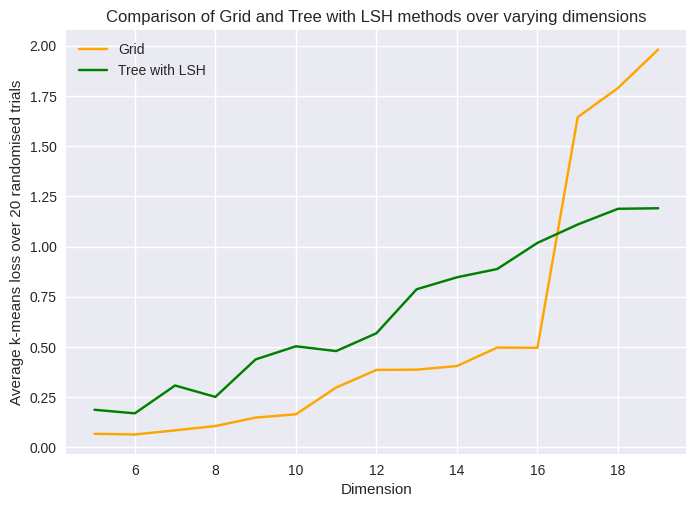

In [6]:
plt.style.use('seaborn-v0_8') 
plt.plot(list(range(5,20,1)), loss_grid_grid[:, 5], c="orange")
plt.plot(list(range(5,20,1)), loss_grid_lsh[:,5], c="green")

plt.xlabel("Dimension")
plt.ylabel("Average k-means loss over 20 randomised trials")
plt.legend(["Grid", "Tree with LSH"])
plt.title("Comparison of Grid and Tree with LSH methods over varying dimensions")

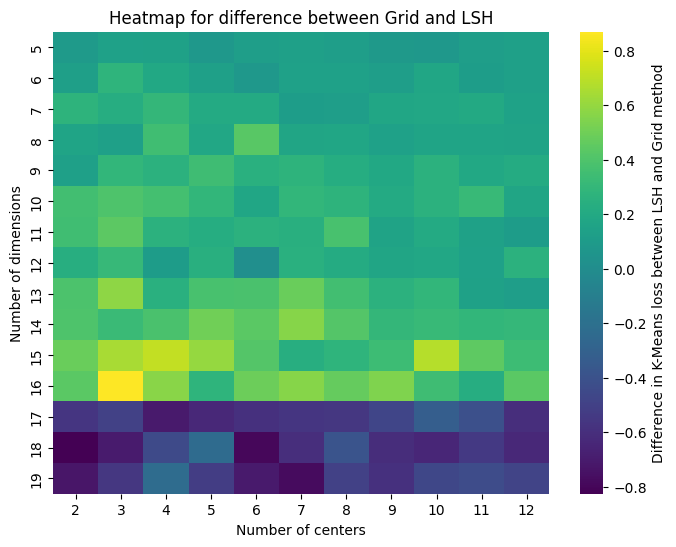

In [9]:
loss_grid_diff = loss_grid_lsh - loss_grid_grid

plt.figure(figsize=(8, 6))
sns.heatmap(loss_grid_diff,
            xticklabels=np.round(k_vals, 2),
            yticklabels=np.round(d_vals, 2),
            cmap="viridis",
            cbar_kws={"label": "Difference in K-Means loss between LSH and Grid method"} )

plt.xlabel("Number of centers")
plt.ylabel("Number of dimensions")
plt.title("Heatmap for difference between Grid and LSH")
plt.show()
